In [1]:
#Jacobi
import numpy as np
def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    print(x)
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        # Check for convergence
        err = np.linalg.norm(x_new - x, ord=np.inf) #Added errors list for easier plotting
        errors.append(err)
        
        if err < tol:
            return x_new, k, errors
        x = x_new
        print(x)
        
    return x, max_iterations, errors

In [2]:
#Gauss-Seidel
import numpy as np
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    print(x)
    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
        
        err = np.linalg.norm(x_new - x, ord=np.inf) #Added errors list for easier plotting
        errors.append(err)
        
        if err < tol:
            return x_new, k, errors
        x = x_new
        print(x)
    return x, max_iterations, errors

[0. 0. 0.]
[ 2.61666667 -2.75714286  7.14      ]
[ 3.0007619  -2.48852381  7.00635714]
[ 3.00080635 -2.49973844  7.00020667]
[0. 0. 0.]
[ 2.61666667 -2.75714286  7.14      ]
[ 3.0007619  -2.48852381  7.00635714]
[ 3.00080635 -2.49973844  7.00020667]
[ 3.0000225  -2.50000266  6.99998104]
[ 2.99999865 -2.50000113  6.99999927]
[ 2.99999991 -2.50000001  7.00000002]
[0. 0. 0.]
[ 2.61666667 -2.75714286  7.14      ]
[ 3.0007619  -2.48852381  7.00635714]
[ 3.00080635 -2.49973844  7.00020667]
[ 3.0000225  -2.50000266  6.99998104]
[ 2.99999865 -2.50000113  6.99999927]
[ 2.99999991 -2.50000001  7.00000002]
[ 3.  -2.5  7. ]
[ 3.  -2.5  7. ]
[0. 0. 0.]
[ 2.61666667 -2.79452381  7.00560952]
[ 2.99055651 -2.49962468  7.00029081]
[ 3.0000319  -2.49998799  6.99999928]
[0. 0. 0.]
[ 2.61666667 -2.79452381  7.00560952]
[ 2.99055651 -2.49962468  7.00029081]
[ 3.0000319  -2.49998799  6.99999928]
[ 3.00000035 -2.50000004  6.99999999]
[0. 0. 0.]
[ 2.61666667 -2.79452381  7.00560952]
[ 2.99055651 -2.49962468  

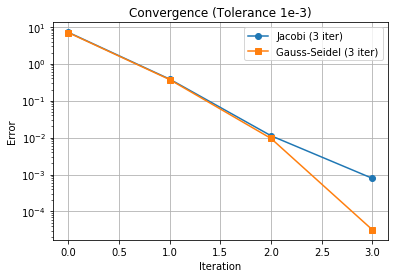

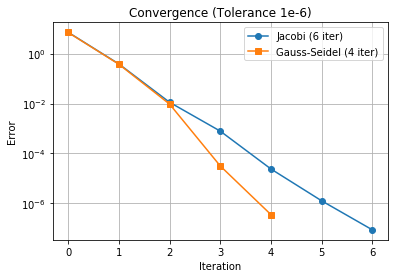

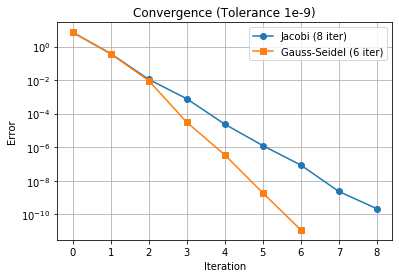

Jacobi with tolerance 1e-3 needed 3 iterations.
Gauss-Seidel with tolerance 1e-3 needed 3 iterations.
Jacobi with tolerance 1e-6 needed 6 iterations.
Gauss-Seidel with tolerance 1e-6 needed 4 iterations.
Jacobi with tolerance 1e-9 needed 8 iterations.
Gauss-Seidel with tolerance 1e-9 needed 6 iterations.


In [4]:
import matplotlib.pyplot as plt

A = np.array([[3, -0.1, -0.2],
              [0.1, 7, -0.3],
              [0.3, -0.2, 10]])

b = np.array([7.85, -19.3, 71.4])
x0 = np.zeros_like(b)
iterations = 100
tol1 = 1e-3
tol2 = 1e-6
tol3 = 1e-9

solutions_j1, iterations_j1, err_j1 = jacobi(A, b, x0, tol1, iterations)
solutions_j2, iterations_j2, err_j2 = jacobi(A, b, x0, tol2, iterations)
solutions_j3, iterations_j3, err_j3= jacobi(A, b, x0, tol3, iterations)

solutions_g1, iterations_g1, err_g1 = gauss_seidel(A, b, x0, tol1, iterations)
solutions_g2, iterations_g2, err_g2 = gauss_seidel(A, b, x0, tol2, iterations)
solutions_g3, iterations_g3, err_g3 = gauss_seidel(A, b, x0, tol3, iterations)

# Plotting
import matplotlib.pyplot as plt

#Graph 1: Tolerance 1e-3
plt.figure()
plt.plot(err_j1, label=f'Jacobi ({iterations_j1} iter)', marker='o')
plt.plot(err_g1, label=f'Gauss-Seidel ({iterations_g1} iter)', marker='s')
plt.yscale('log')
plt.title('Convergence (Tolerance 1e-3)')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()

#Graph 2: Tolerance 1e-6
plt.figure()
plt.plot(err_j2, label=f'Jacobi ({iterations_j2} iter)', marker='o')
plt.plot(err_g2, label=f'Gauss-Seidel ({iterations_g2} iter)', marker='s')
plt.yscale('log')
plt.title('Convergence (Tolerance 1e-6)')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()

#Graph 3: Tolerance 1e-9
plt.figure()
plt.plot(err_j3, label=f'Jacobi ({iterations_j3} iter)', marker='o')
plt.plot(err_g3, label=f'Gauss-Seidel ({iterations_g3} iter)', marker='s')
plt.yscale('log')
plt.title('Convergence (Tolerance 1e-9)')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()

print(f"Jacobi with tolerance 1e-3 needed {iterations_j1} iterations.")
print(f"Gauss-Seidel with tolerance 1e-3 needed {iterations_g1} iterations.")

print(f"Jacobi with tolerance 1e-6 needed {iterations_j2} iterations.")
print(f"Gauss-Seidel with tolerance 1e-6 needed {iterations_g2} iterations.")

print(f"Jacobi with tolerance 1e-9 needed {iterations_j3} iterations.")
print(f"Gauss-Seidel with tolerance 1e-9 needed {iterations_g3} iterations.")

Stricter tolerances increase the iteration count because the algorithm must perform more cycles to achieve higher precision. Since both methods exhibit linear convergence, adding extra decimal places of accuracy requires a constant amount of additional work. Gauss-Seidel manages this increase more efficiently than Jacobi. Gauss-Seidel's steeper convergence rate means that as the tolerance becomes more demanding, it saves a greater number of iterations by comparison, reaching high-precision targets significantly faster.